# Optimagic-native fitting API

This notebook exercises the new `sigmondsamplings.fitting` API. The fitting
stack is centered on `optimagic`:

- `ParamSpec` / `ParamSetSpec` declare fit parameters, bounds, fixed parameters,
  constraints, and output metadata, then `.resolve()` into the canonical
  `ParamSetResolved` the fit driver consumes.
- `CallableModel` adapts a numerical model to the optimizer-facing contract:
  `params dict -> flat theory vector`.
- `LeastSquaresObjective` builds a cached whitening transform from
  `SamplingStats` and returns optimagic-marked least-squares residuals.
- `SamplingFit` runs one full-sample fit, optionally runs every resampling, and
  returns a `FitResult` with parameter `SamplingStats`, chi-squared sampling,
  theory predictions, and the native optimagic result.

We build synthetic bootstrap data for a one-state exponential correlator

$$ C(t) = A\, e^{-E t}, $$

then fit it with correlated residuals.

The fitting API requires the optional fitting dependencies. Install them with
`pip install -e .[fitting]` from this source checkout, or install `optimagic`
directly.

In [ ]:
from __future__ import annotations

try:
    import optimagic  # noqa: F401
except ImportError as exc:
    raise ImportError(
        "This notebook uses the optimagic-native fitting API. "
        "Install dependencies with: pip install -e .[fitting]"
    ) from exc

import matplotlib.pyplot as plt
import numpy as np

from sigmondsamplings.fitting import (
    CallableModel,
    Chi2PlotStyle,
    FitPlotStyle,
    MinimizerConfig,
    ParamSetSpec,
    ParamSpec,
    SamplingFit,
    available_algorithms,
    plot_chi2_2d,
    plot_fit_result,
)
from sigmondsamplings.info import ObservableInfo, SamplingInfo
from sigmondsamplings.sampling import SigmondSampling
from sigmondsamplings.stats import SamplingStats
from sigmondsamplings.plotting import SamplingPlotter

rng = np.random.default_rng(20240519)


## 1. Synthetic bootstrap data

Each time slice `t` becomes one observable. `y_samples[0]` is the full sample
(`resamp_idx=0`); the remaining rows are bootstrap resamples drawn around it.
Every time slice is wrapped as a `SigmondSampling` and collected into a
`SamplingStats`, which supplies the covariance used by the fit objective.

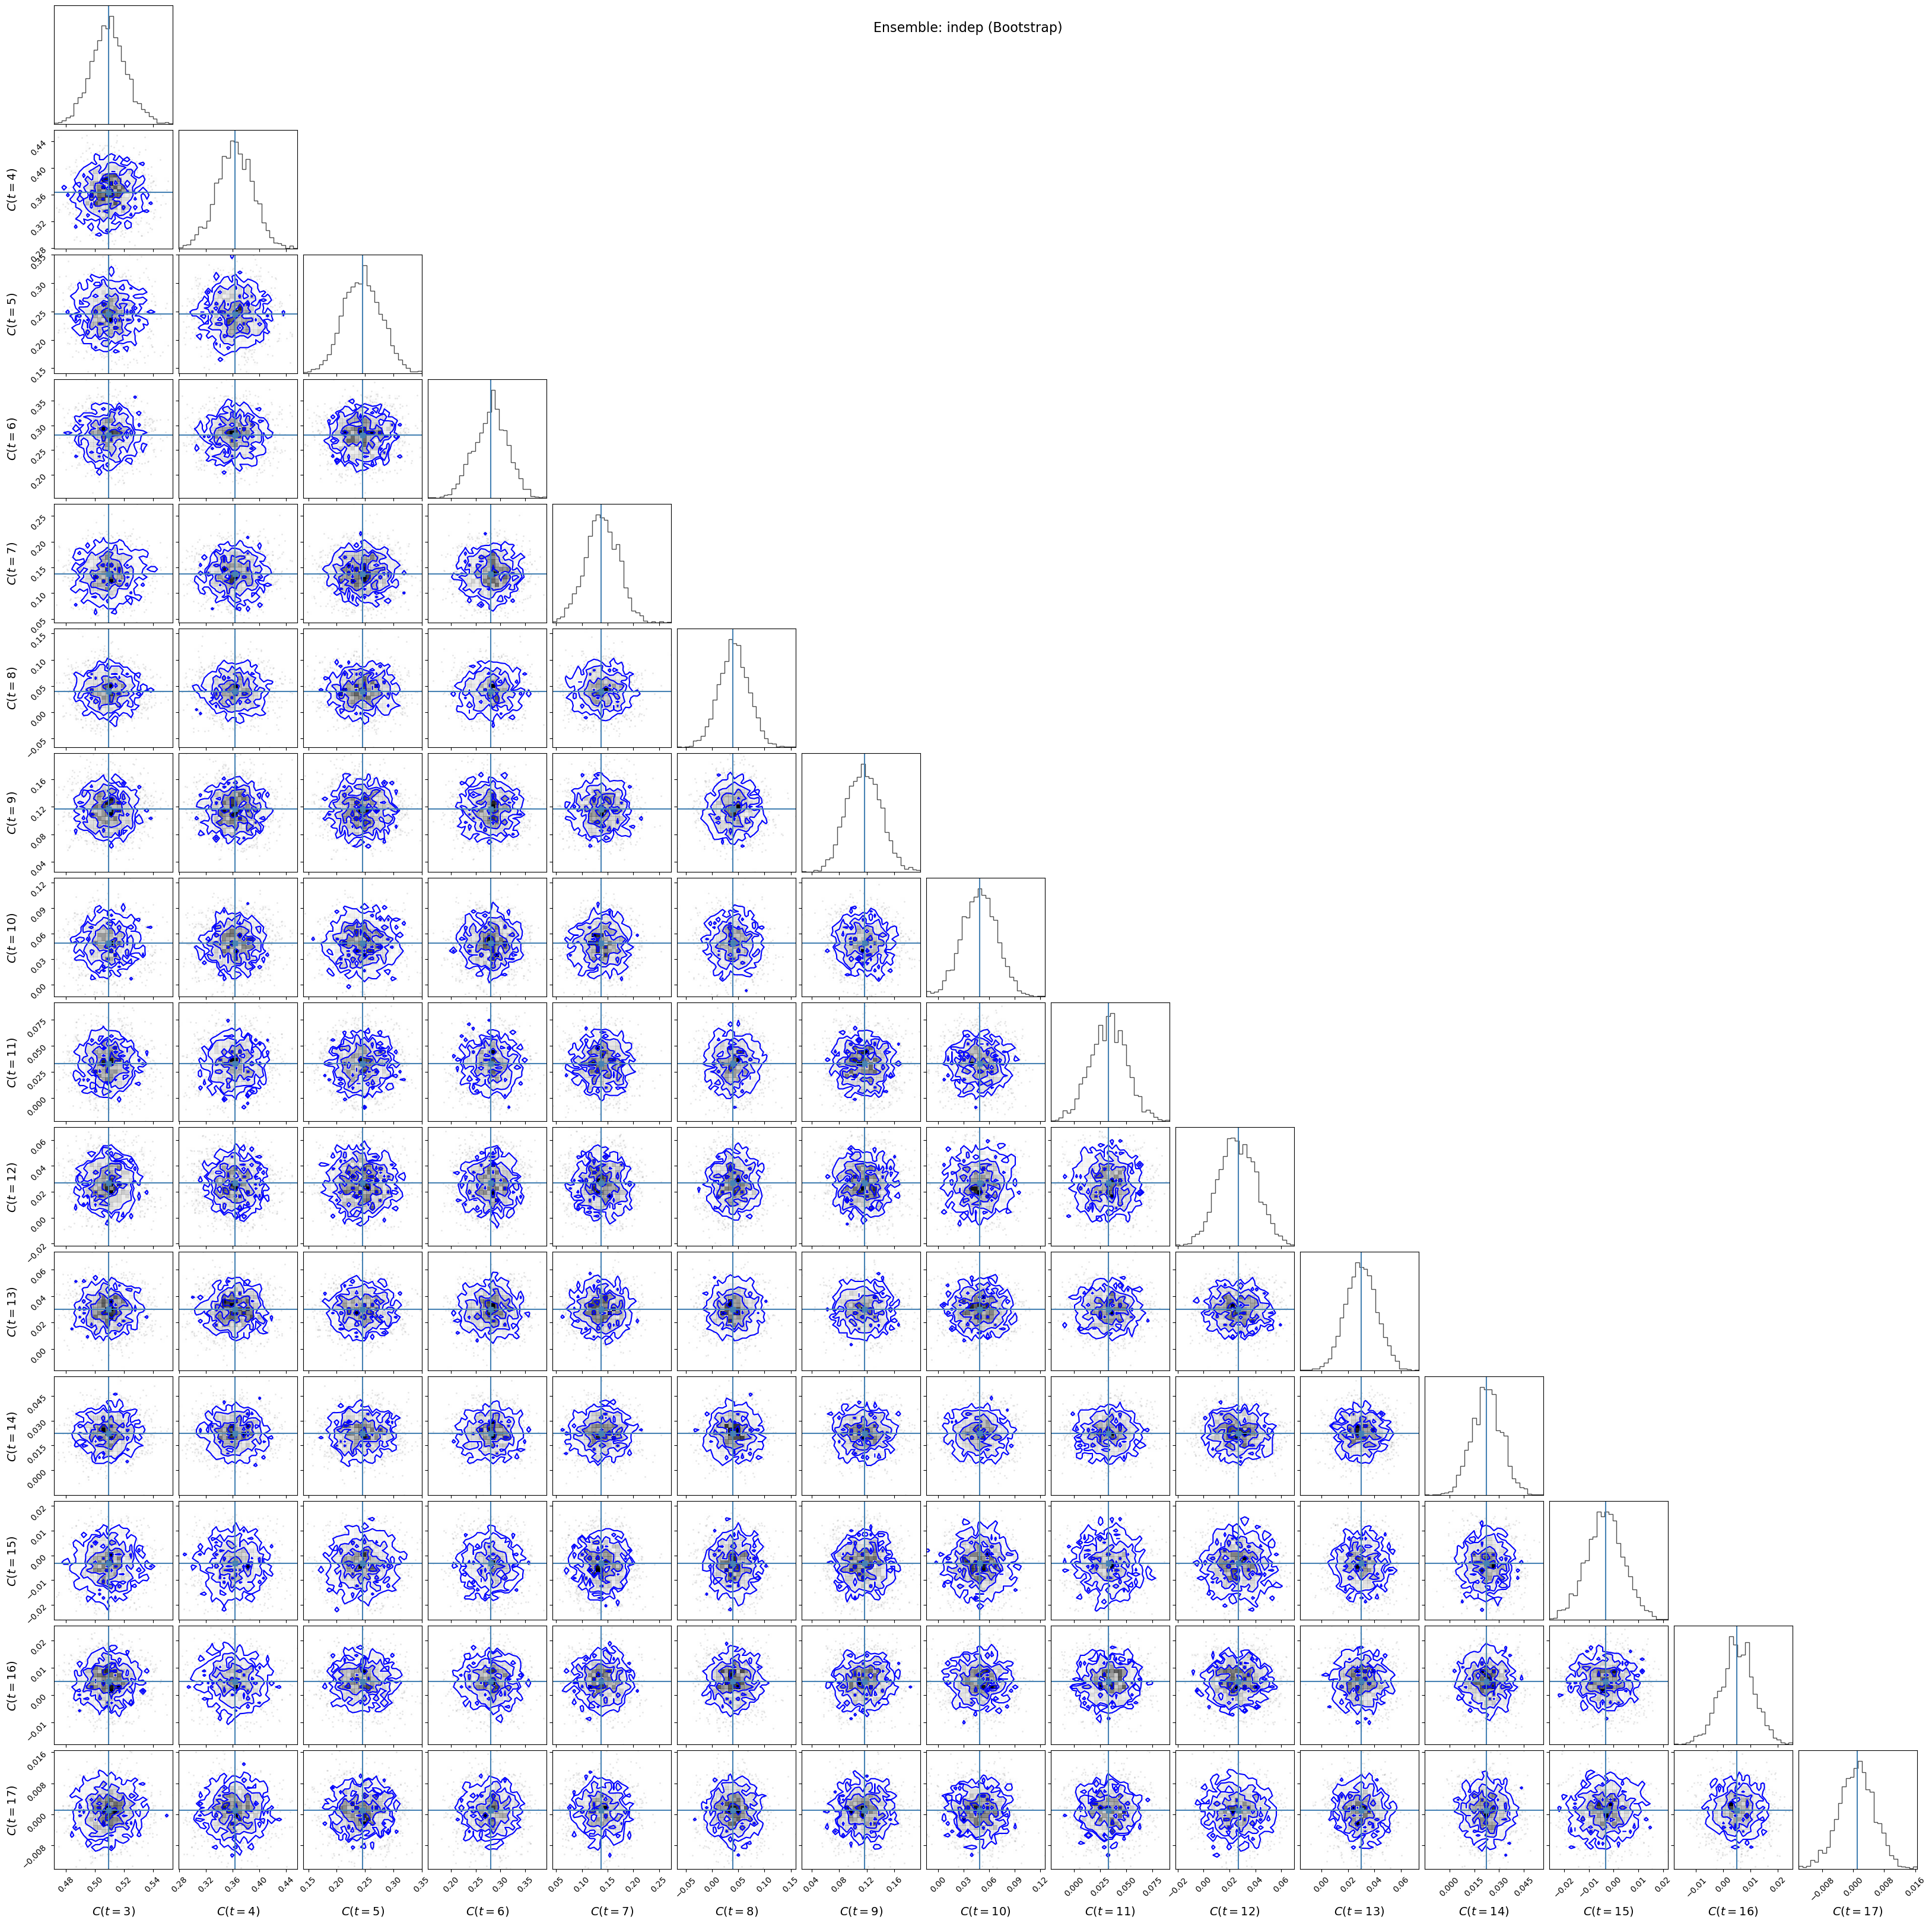

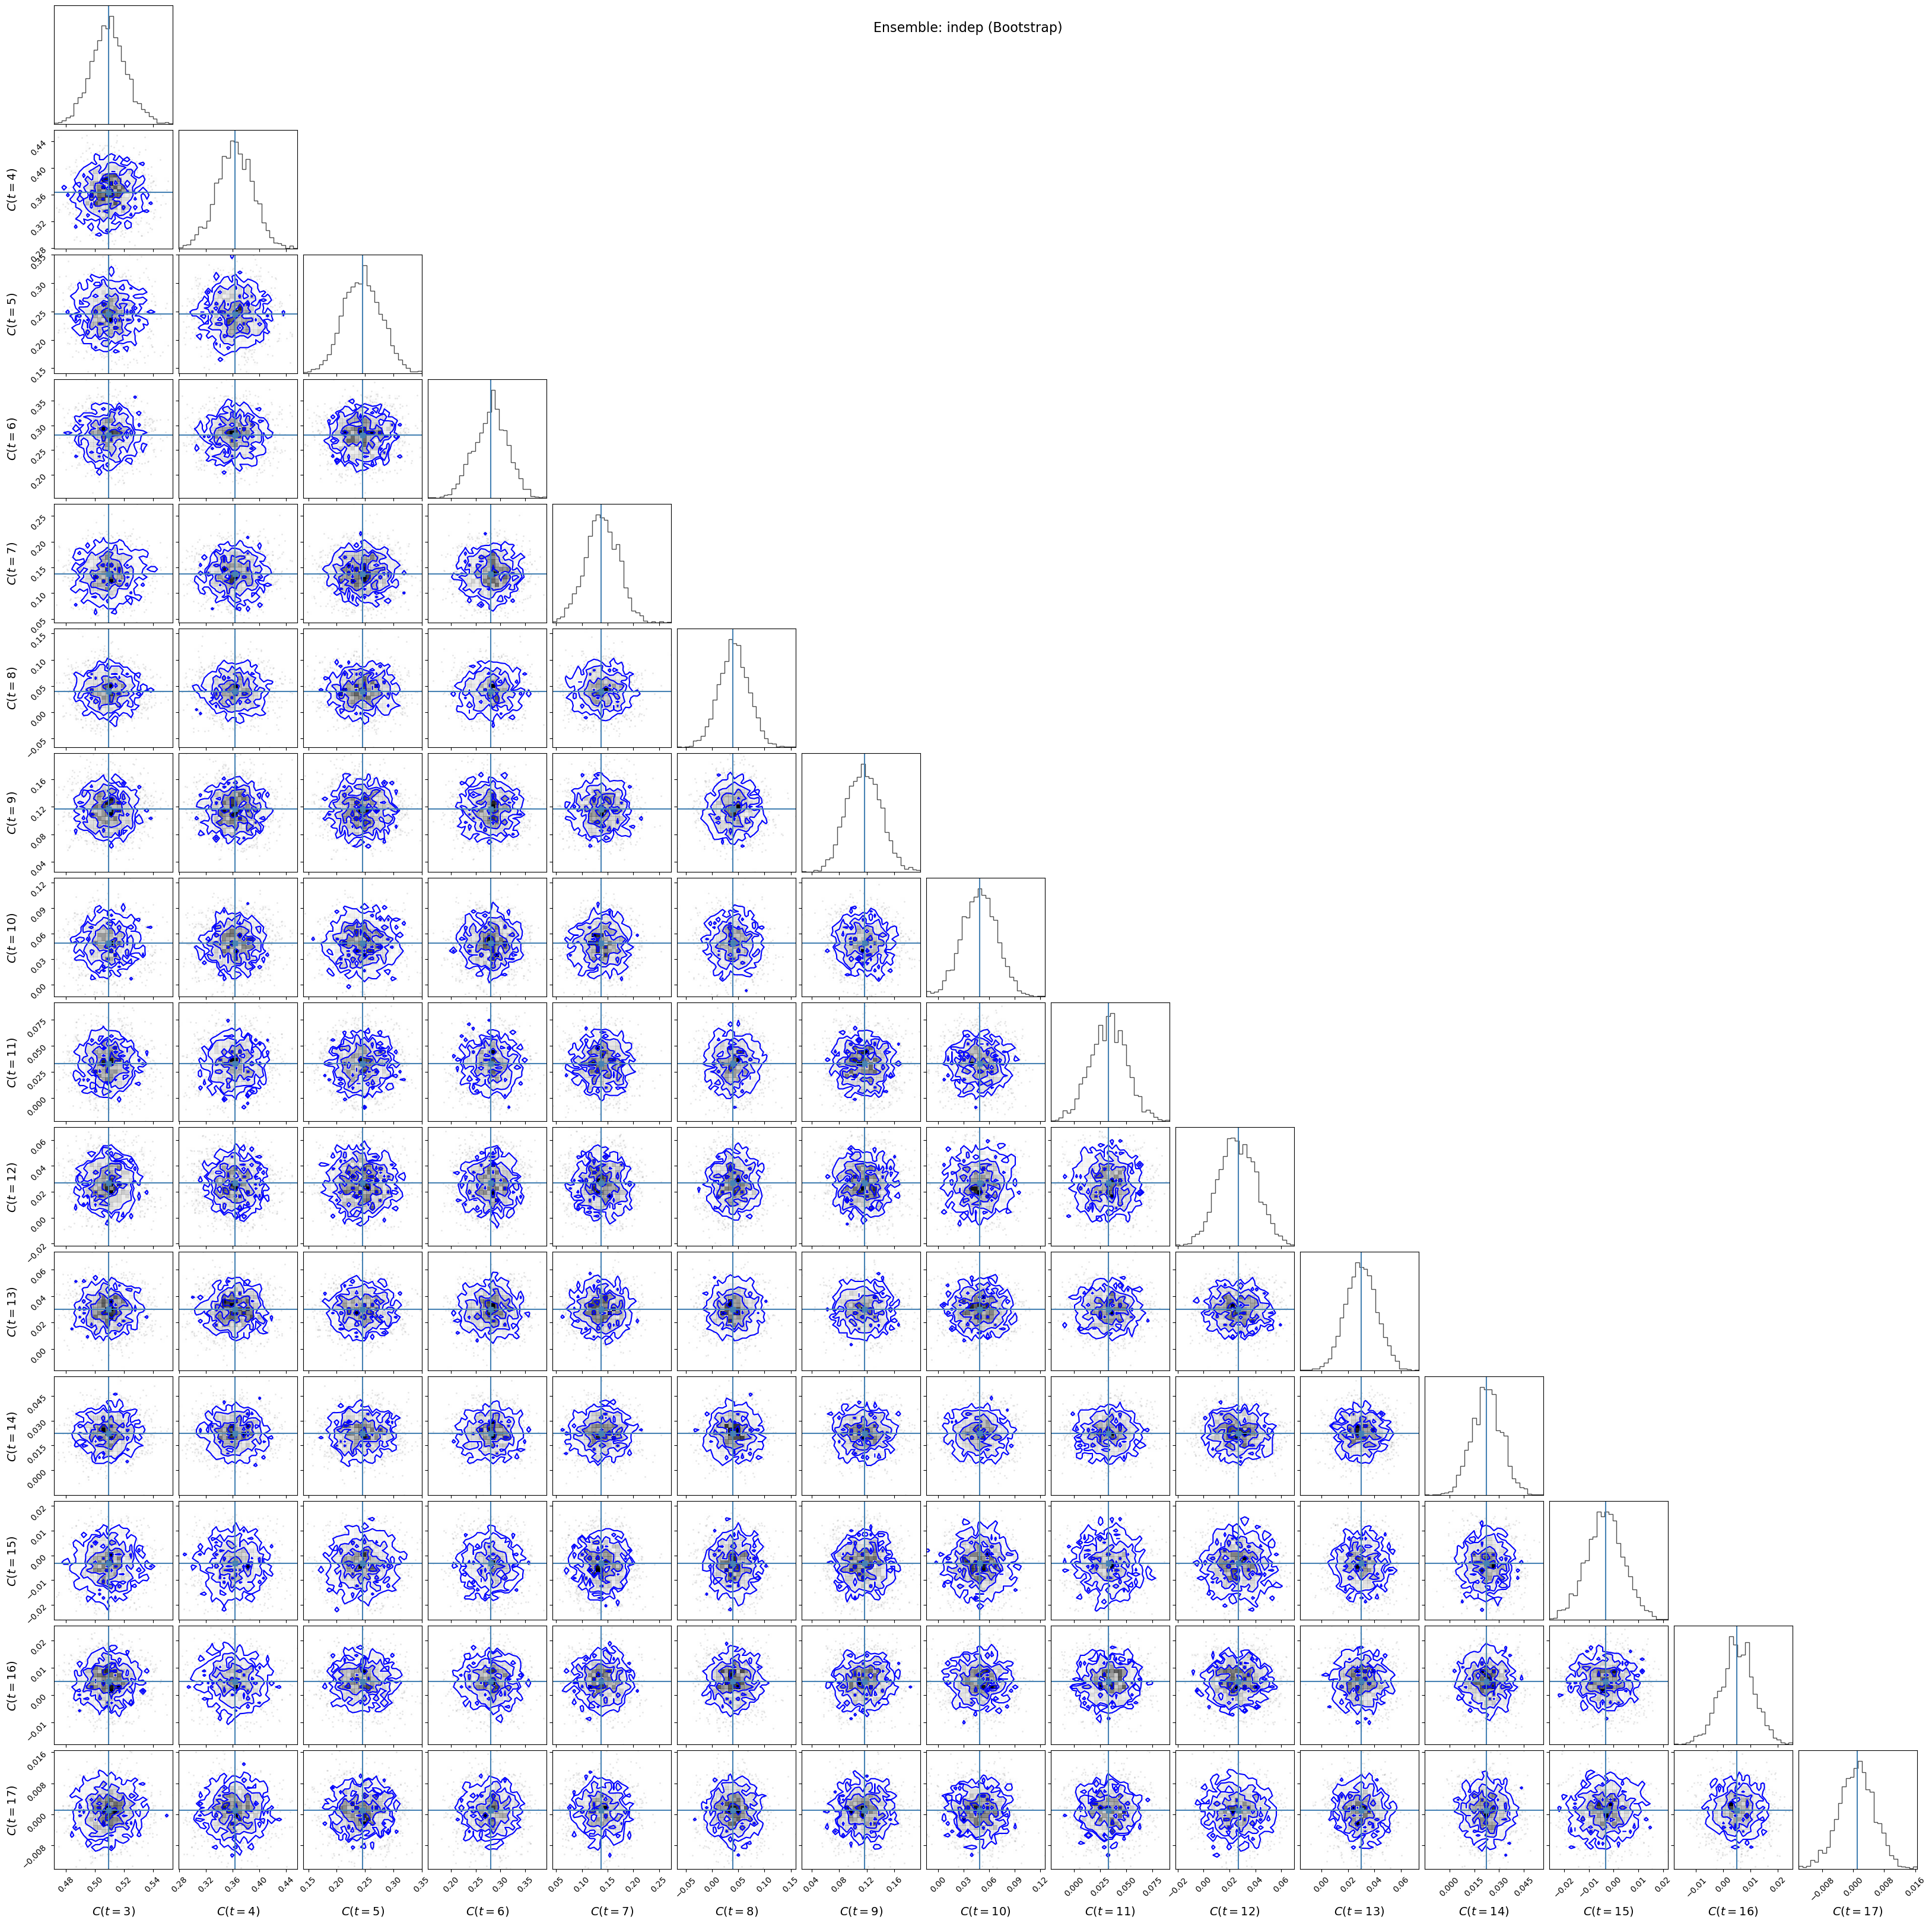

In [2]:
t = np.arange(3, 18, dtype=float)
true_params = np.array([1.25, 0.31])  # (A, E)
n_resamplings = 2000


def correlator(theta, x):
    amplitude, energy = theta
    return amplitude * np.exp(-energy * x)


true_mean = correlator(true_params, t)
rel_err = 0.025 + 0.05 * (t - t.min())
sigma = rel_err * true_mean
full_mean = true_mean + rng.normal(scale=sigma)

y_samples = np.empty((n_resamplings + 1, len(t)), dtype=float)
y_samples[0] = full_mean
y_samples[1:] = full_mean + rng.normal(scale=sigma, size=(n_resamplings, len(t)))

sampling_info = SamplingInfo("bootstrap", n_resamplings, seed=20240519)

data_samplings = [
    SigmondSampling(
        data=y_samples[:, i],
        observable_info=ObservableInfo(
            name=f"C_t{int(t[i])}",
            index=i,
            latex_str=rf"C(t={int(t[i])})",
        ),
        sampling_info=sampling_info,
    )
    for i in range(len(t))
]

stats = SamplingStats(data_samplings)
plotter = SamplingPlotter(stats)
plotter.plot_corner()

## 2. Model, parameters, and minimizer

The fit model returns a flat theory vector in the same order as `stats`. The
parameter set is keyed by parameter name, matching optimagic's dict-PyTree
params. Bounds and latex labels live on the `ParamSpec`s.

In [ ]:
def theory_vector(theta):
    return correlator(theta, t)

model = CallableModel(theory_vector, ["amplitude", "energy"])

# Parameter names are the keys of the values mapping; resolve() produces the
# canonical, optimagic-facing ParamSetResolved consumed by the fit driver.
param_spec = ParamSetSpec(
    values={
        "amplitude": ParamSpec(initial=1.0, bounds=[0.0, 2.0], latex=r"A"),
        "energy": ParamSpec(initial=0.25, bounds=[0.0, 2.0], latex=r"E"),
    }
)
param_set = param_spec.resolve()

minimizer = MinimizerConfig(algorithm="scipy_ls_lm").resolved()

print("start values:", param_set.start_values())
print("minimizer:", minimizer.model_dump_json(indent=2))
print("first available algorithms:", available_algorithms()[:8])


## 3. Run the resampled fit

`SamplingFit.from_model` builds a `LeastSquaresObjective` from `SamplingStats`
and the model. `fit_resampled` first fits the full sample, then uses that result
as the starting point for every bootstrap resample. The notebook uses the
thread backend because notebook-defined callables are not always process-pickle
friendly; use `backend="process"` for module-level models in scripts.


In [13]:
fit = SamplingFit.from_model(
    stats,
    model,
    param_set,
    minimizer=minimizer,
    use_correlation=True,
)

result = fit.fit_resampled(
    backend="serial",
    num_workers=4,
    progress=True,
)
result


Resample fits:   0%|          | 0/2000 [00:00<?, ?it/s]

FitResult(n_params=2, chi2=20.4996, dof=13, is_synthetic=False, n_failed=0)

In [ ]:
result.optimize_result

Minimize with 2 free parameters terminated successfully after 6 criterion evaluations and 5 derivative evaluations.

The value of criterion improved from 65.20716450538093 to 20.49961723572443.

The scipy_ls_lm algorithm reported: `ftol` termination condition is satisfied.

Independent of the convergence criteria used by scipy_ls_lm, the strength of convergence can be assessed by the following criteria:

                          one_step   five_steps 
relative_criterion_change   0***    1.467e-07*  
relative_params_change      0***    0.0001242   
absolute_criterion_change   0***    3.007e-06*  
absolute_params_change      0***    0.0001271   

(***: change <= 1e-10, **: change <= 1e-8, *: change <= 1e-5. Change refers to a change between accepted steps. The first column only considers the last step. The second column considers the last five steps.)

In [6]:
for name, true_val in zip(["amplitude", "energy"], true_params):
    s = result.param(name)
    print(s.latex_str)
    print(f"  truth = {true_val:.6f}\n")

print(f"full-sample chi^2 = {result.chi2:.4f}")
print(f"dof = {result.dof}")
print(f"chi^2/dof = {result.chi2_per_dof:.4f}")
print(f"Q = {result.goodness_of_fit():.4f}")
print(f"fits attempted = {result.n_fits}")
print(f"failed resamples = {result.n_failed}")

A = 1.370(81)
  truth = 1.250000

E = 0.329(16)
  truth = 0.310000

full-sample chi^2 = 20.4996
dof = 13
chi^2/dof = 1.5769
Q = 0.0834
fits attempted = 2000
failed resamples = 2


## 4. Inspect the parameter distributions

`result.params` is a `SamplingStats` over the fitted parameters. The chi-squared
values are stored separately in `result.chi_squared`.

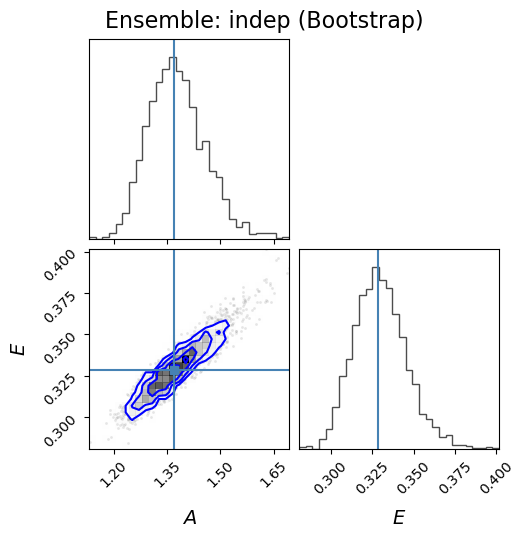

In [7]:
plotter = SamplingPlotter(result.params)
fig = plotter.plot_corner()

## 5. Build the full post-fit model function

The fit-time model maps a parameter vector to the finite set of fitted
observables. The post-fit `SigmondModelFunc` is the full human-facing model:
it takes an independent variable `x`, uses the fitted parameter samplings, and
propagates uncertainties through `SigmondSampling` arithmetic. The plotting API
accepts this object directly.


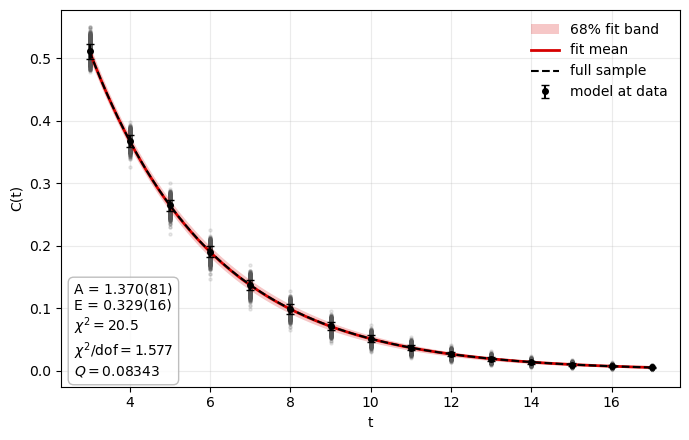

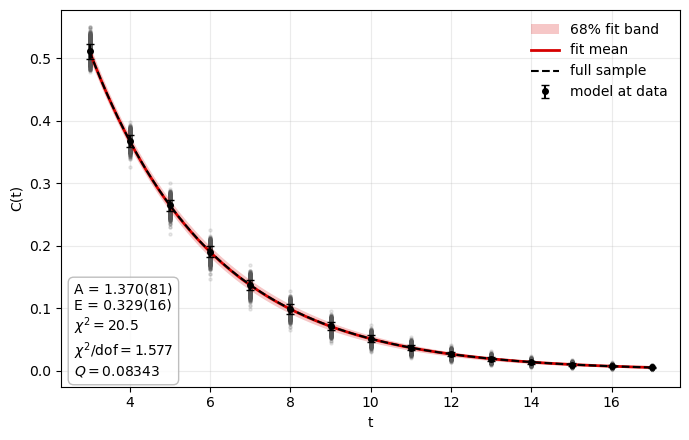

In [8]:
def exp_model(x, amplitude, energy):
    return amplitude * np.exp(-energy * x)


curve = result.model_func(
    exp_model,
    latex_str=r"A e^{-E {VAR}}",
    independent_var_latex="t",
)

x_fit = np.linspace(float(t.min()), float(t.max()), 200)
fig, ax = plot_fit_result(
    t,
    curve,
    x_fit_values=x_fit,
    data_samplings=data_samplings,
    figsize=(7, 4.5),
    style=FitPlotStyle(
        show_data=True,
        display_params=True,
        metrics=("chi_squared", "chi2_per_dof", "goodness_of_fit"),
        annotation_loc="lower left",
        xlabel="t",
        ylabel="C(t)",
        band_label=r"68% fit band",
        mean_label="fit mean",
    ),
)
# ax.errorbar(
#     t,
#     [s.full_sample_value for s in data_samplings],
#     yerr=[s.error for s in data_samplings],
#     fmt="o",
#     color="black",
#     capsize=3,
#     label="data",
#     zorder=12,
# )
# ax.set_yscale("log")
ax.legend(frameon=False)
fig


## 6. A 2D $\chi^2$ scan

`plot_chi2_2d` wraps the scan machinery and renders the landscape directly. It
uses the same whitening path as the fit objective and marks the minimum on the
surface.


In [18]:
a_best = result.param("amplitude").full_sample_value
e_best = result.param("energy").full_sample_value

result_fig = plot_chi2_2d(
    stats,
    prediction_func=theory_vector,
    param_indices=(0, 1),
    param_ranges=((0.8 * a_best, 1.2 * a_best), (0.8 * e_best, 1.2 * e_best)),
    n_points=(60, 60),
    param_names=[r"amplitude $A$", r"energy $E$"],
    backend="serial",
    num_workers=4,
    progress=True,
    figsize=(6, 5),
    use_plotly=True,
    style=Chi2PlotStyle(
        # xlabel=r"amplitude $A$",
        # ylabel=r"energy $E$",
        min_marker=".",
        min_markersize=6,
    ),
)
result_fig


Chi2 scan:   0%|          | 0/3600 [00:00<?, ?it/s]

## 7. Full-sample Jacobian mode

`fit_full_sample` performs only the full-sample fit, estimates the parameter
covariance from the residual Jacobian, and synthesizes parameter samplings whose
errors reproduce that covariance. This is useful for fast diagnostics, while
`fit_resampled` is the genuine bootstrap/jackknife fit.

In [19]:
jac_result = fit.fit_full_sample(rng=20240519)

print("covariance source:", jac_result.cov_source)
print("synthetic:", jac_result.is_synthetic)
print("standard errors:")
for name, error in jac_result.standard_errors.items():
    print(f"  {name}: {error:.6g}")

covariance source: first_derivative
synthetic: True
standard errors:
  amplitude: 0.0824481
  energy: 0.0167473
